In [39]:
from skimage.io import imread
from skimage.filters import gaussian
from skimage.color import rgb2gray
from matplotlib import pyplot as plt
import numpy as np


In [40]:
img = imread('alok.jpg')
img_gray = rgb2gray(img) if img.ndim == 3 else img.astype(np.float32)

# Garante faixa [0, 1] para imagens já em escala de cinza uint8
if img_gray.max() > 1:
    img_gray = img_gray / 255.0

blurred_image = gaussian(img_gray, sigma=2, channel_axis=None, preserve_range=True)

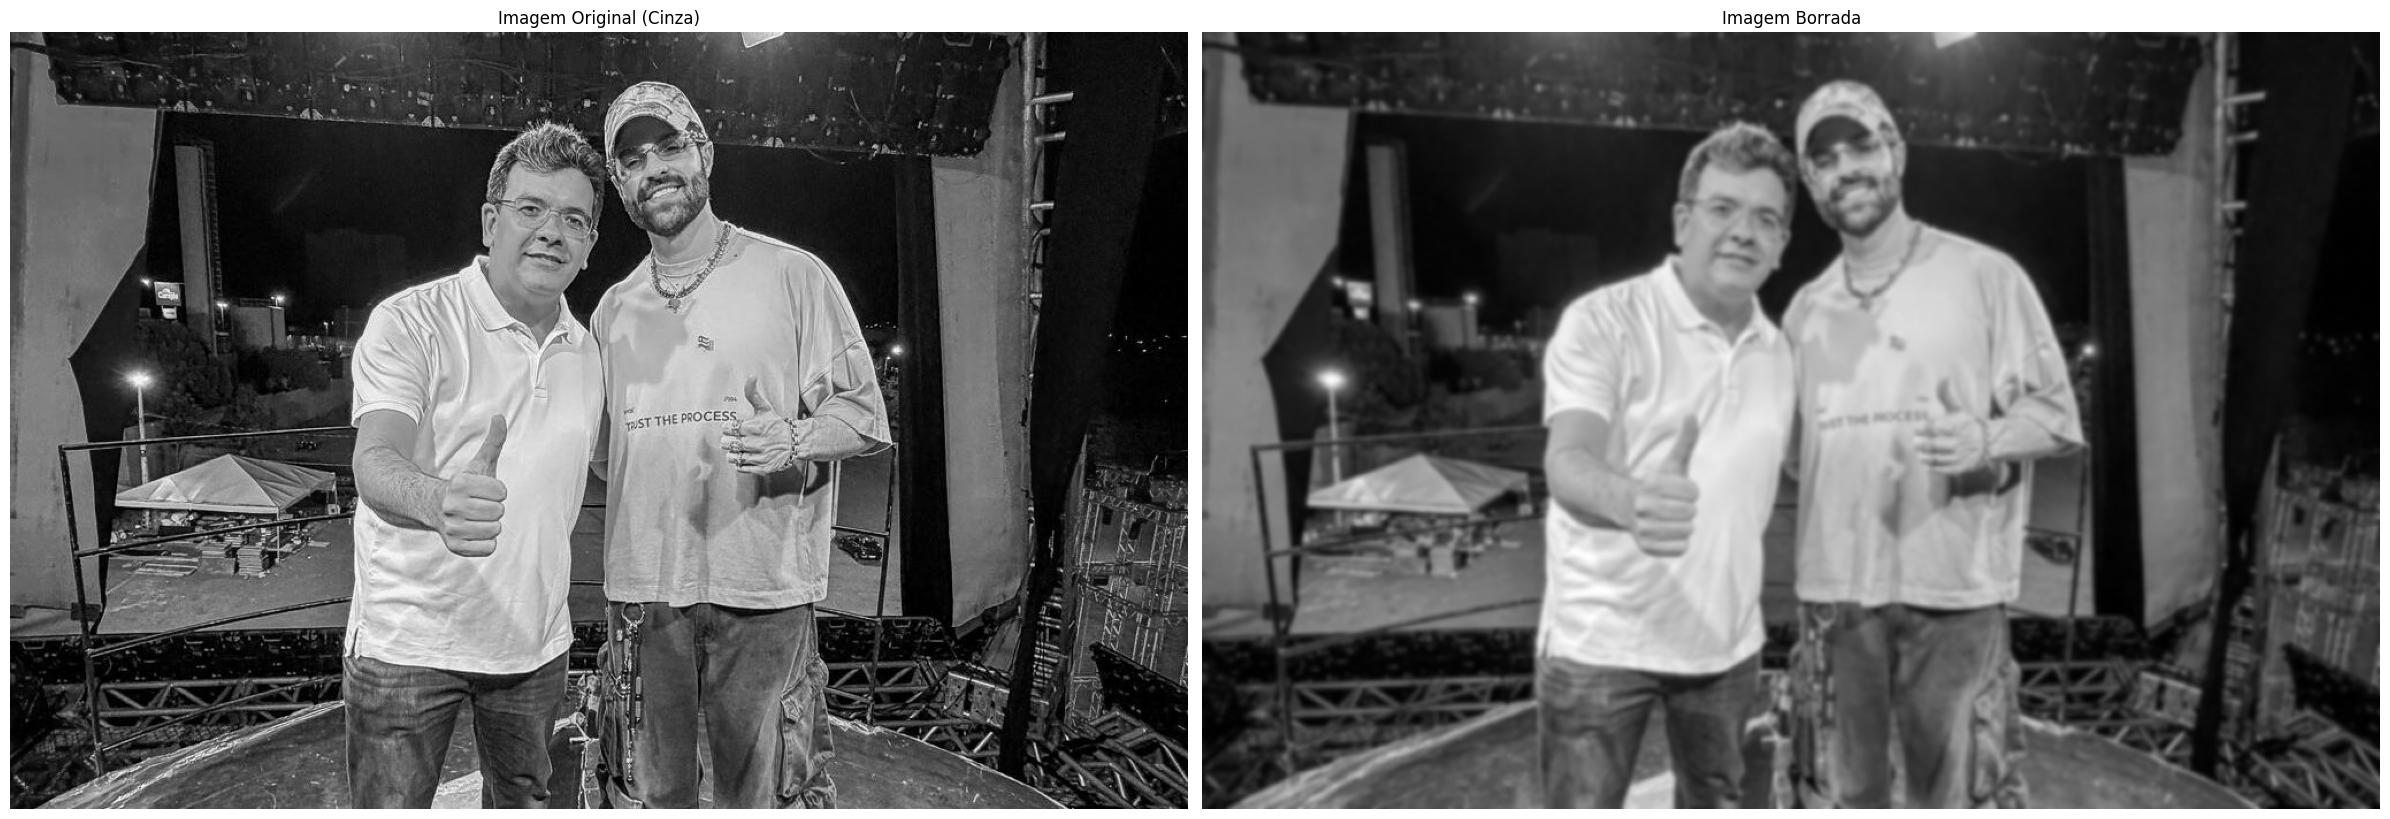

In [41]:
# plot img_gray and blurred_image in the same plot
fig, ax = plt.subplots(1, 2, figsize=(24, 12), sharex=True, sharey=True)

ax[0].imshow(img_gray, cmap='gray')
ax[0].set_title('Imagem Original (Cinza)')
ax[0].axis('off')

ax[1].imshow(blurred_image, cmap='gray')
ax[1].set_title('Imagem Borrada')
ax[1].axis('off')

plt.tight_layout()

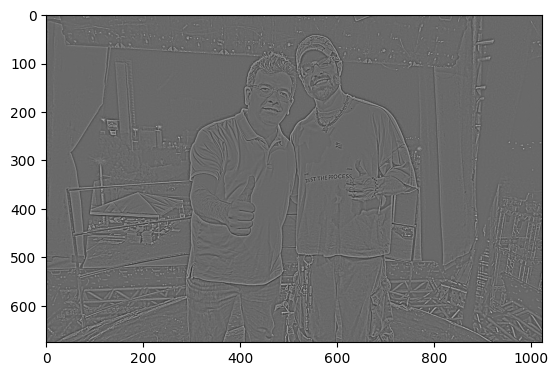

In [42]:
unsharp_mask = img_gray - blurred_image
plt.imshow(unsharp_mask, cmap='gray')
plt.show()


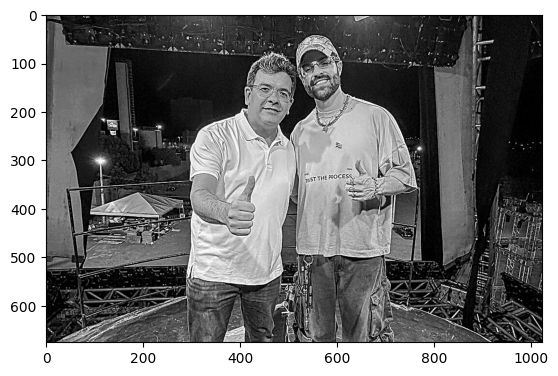

In [43]:
sharpened_image = np.clip(img_gray + unsharp_mask, 0, 1)
plt.imshow(sharpened_image, cmap='gray')
plt.show()